In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_ANALYTICS, BQ_FEATURES_ENGG_TRACT
from network_idx.eda.correlations import (
    compute_all_correlations,
    get_top_correlations,
    plot_correlation_heatmap,
    correlations_with_target
)

In [2]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_FEATURES_ENGG_TRACT}"
client = bigquery.Client(project=GCS_PROJECT_ID)
# Exclude geometry
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df_modified = client.query(query).to_arrow().to_pandas()
tract_df_modified.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 40 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   tract_geoid                                83313 non-null  str    
 1   pop_ch_1yr                                 83313 non-null  float64
 2   pop_ch_avg                                 83313 non-null  float64
 3   pop_pctch_1yr                              83313 non-null  float64
 4   pop_pctch_avg                              83313 non-null  float64
 5   estimated_census_housing_units             83313 non-null  int64  
 6   estimated_fcc_units                        83313 non-null  int64  
 7   copper_speed_1000_100_only                 83313 non-null  float64
 8   cable_speed_1000_100_only                  83313 non-null  float64
 9   fiber_speed_1000_100_only                  83313 non-null  float64
 10  cable_location_count             

In [3]:
# Drop some columns that are not needed for correlation analysis
columns_to_drop = [
    'tract_geoid',
    'estimated_fcc_units', # highly correlated with census units
    'copper_location_count',
    'copper_provider_count',
    'copper_speed_100_to_sub_gig',
    'cable_speed_1000_100_only', # Removing because cable_future_gap = 1 - cable_speed_1000_100_only
    'fiber_location_count',
    'fiber_penetration', # removing because fiber_opportunity_gap = 1 - fiber_penetration
    'fiber_speed_1000_100_only', # Removing because fiber_speed_top_tier = has_fiber * fiber_speed_1000_100_only
    'fiber_opportunity_score' # Highly correlated with fiber_cable_interaction = cable_penetration * fiber_opportunity_gap
]
tract_df_corr = tract_df_modified.copy()
tract_df_corr = tract_df_corr.drop(columns=columns_to_drop)
tract_df_corr.info()

<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 30 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   pop_ch_1yr                                 83313 non-null  float64
 1   pop_ch_avg                                 83313 non-null  float64
 2   pop_pctch_1yr                              83313 non-null  float64
 3   pop_pctch_avg                              83313 non-null  float64
 4   estimated_census_housing_units             83313 non-null  int64  
 5   copper_speed_1000_100_only                 83313 non-null  float64
 6   cable_location_count                       83238 non-null  float64
 7   cable_provider_count                       83313 non-null  int64  
 8   cable_max_download_speed                   80620 non-null  float64
 9   copper_max_download_speed                  67451 non-null  float64
 10  fiber_provider_count             

Figure(1600x1400)


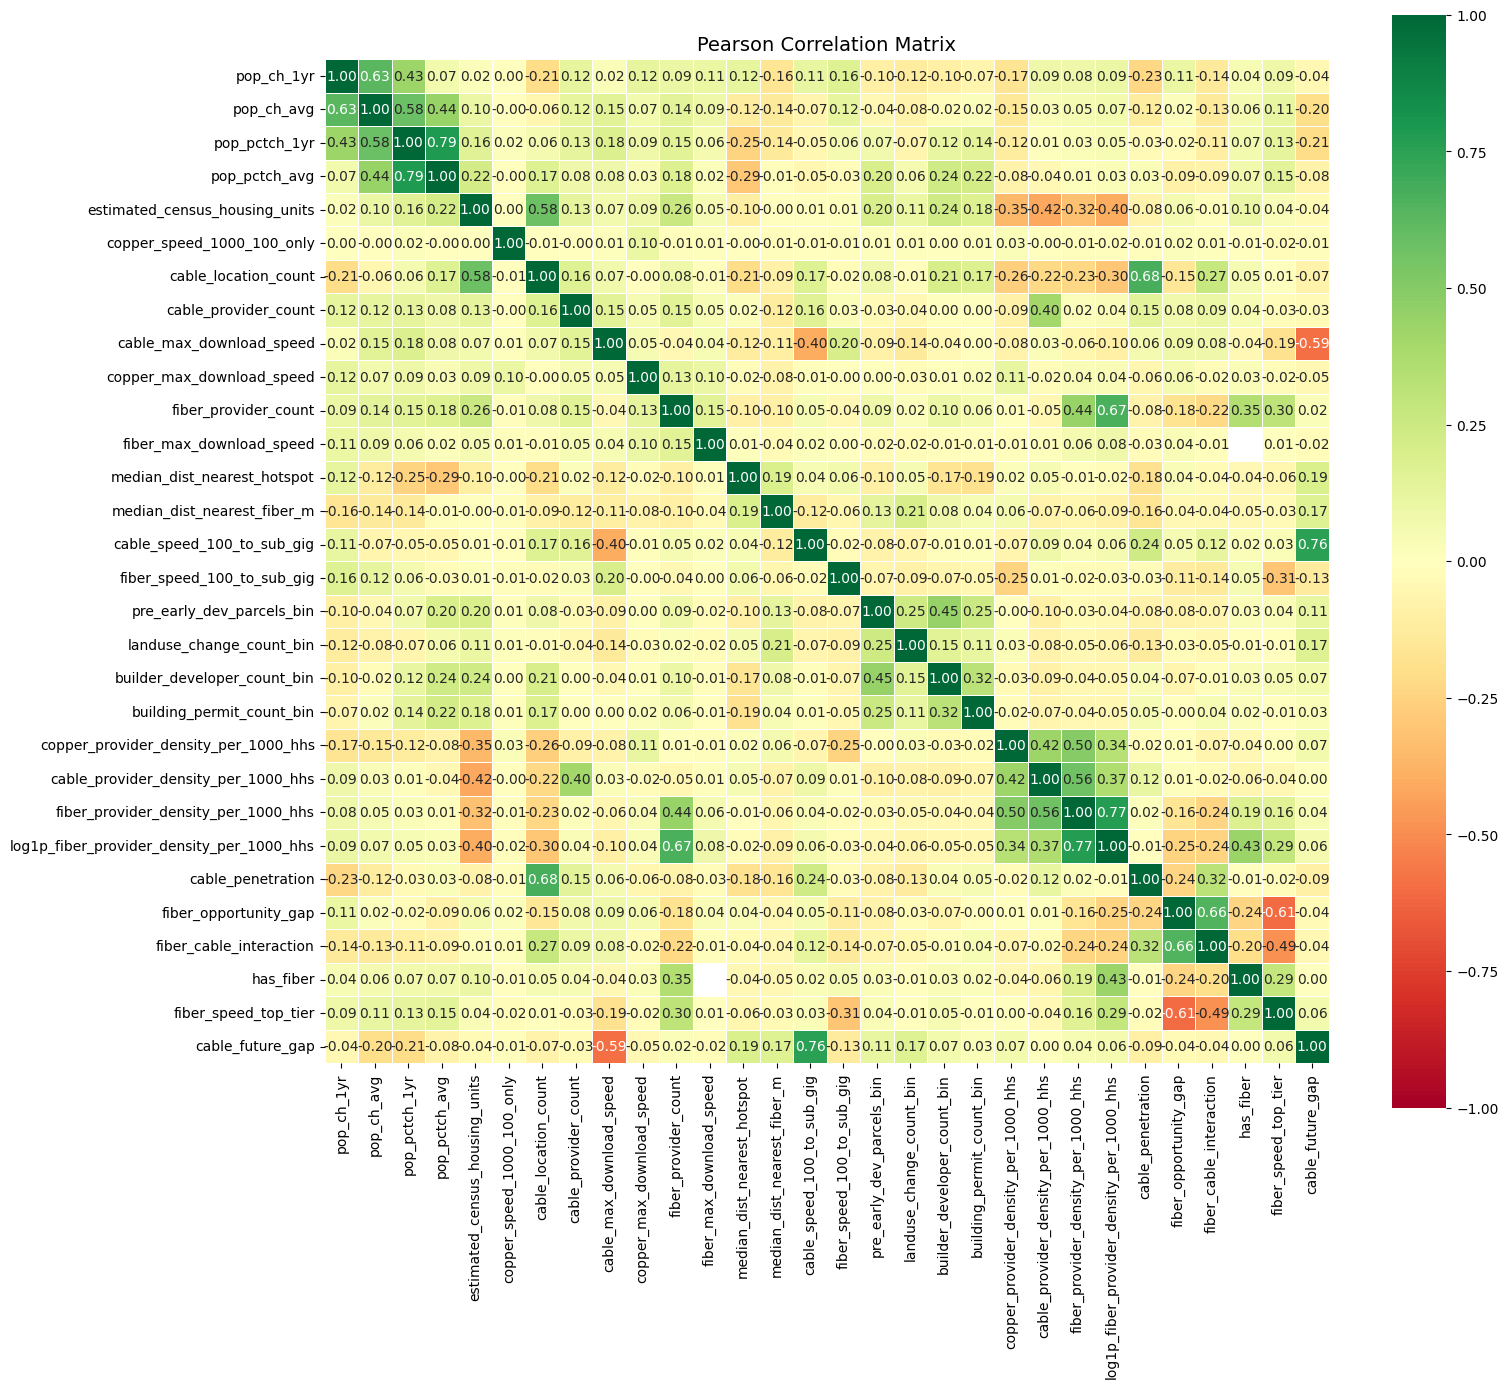

In [4]:
# Compute correlation matrix: pearson correlation that measures linear relationships between features
pearson_corr_matrix = plot_correlation_heatmap(tract_df_corr, method='pearson',cmap= "RdYlGn")
print(pearson_corr_matrix)

Figure(1600x1400)


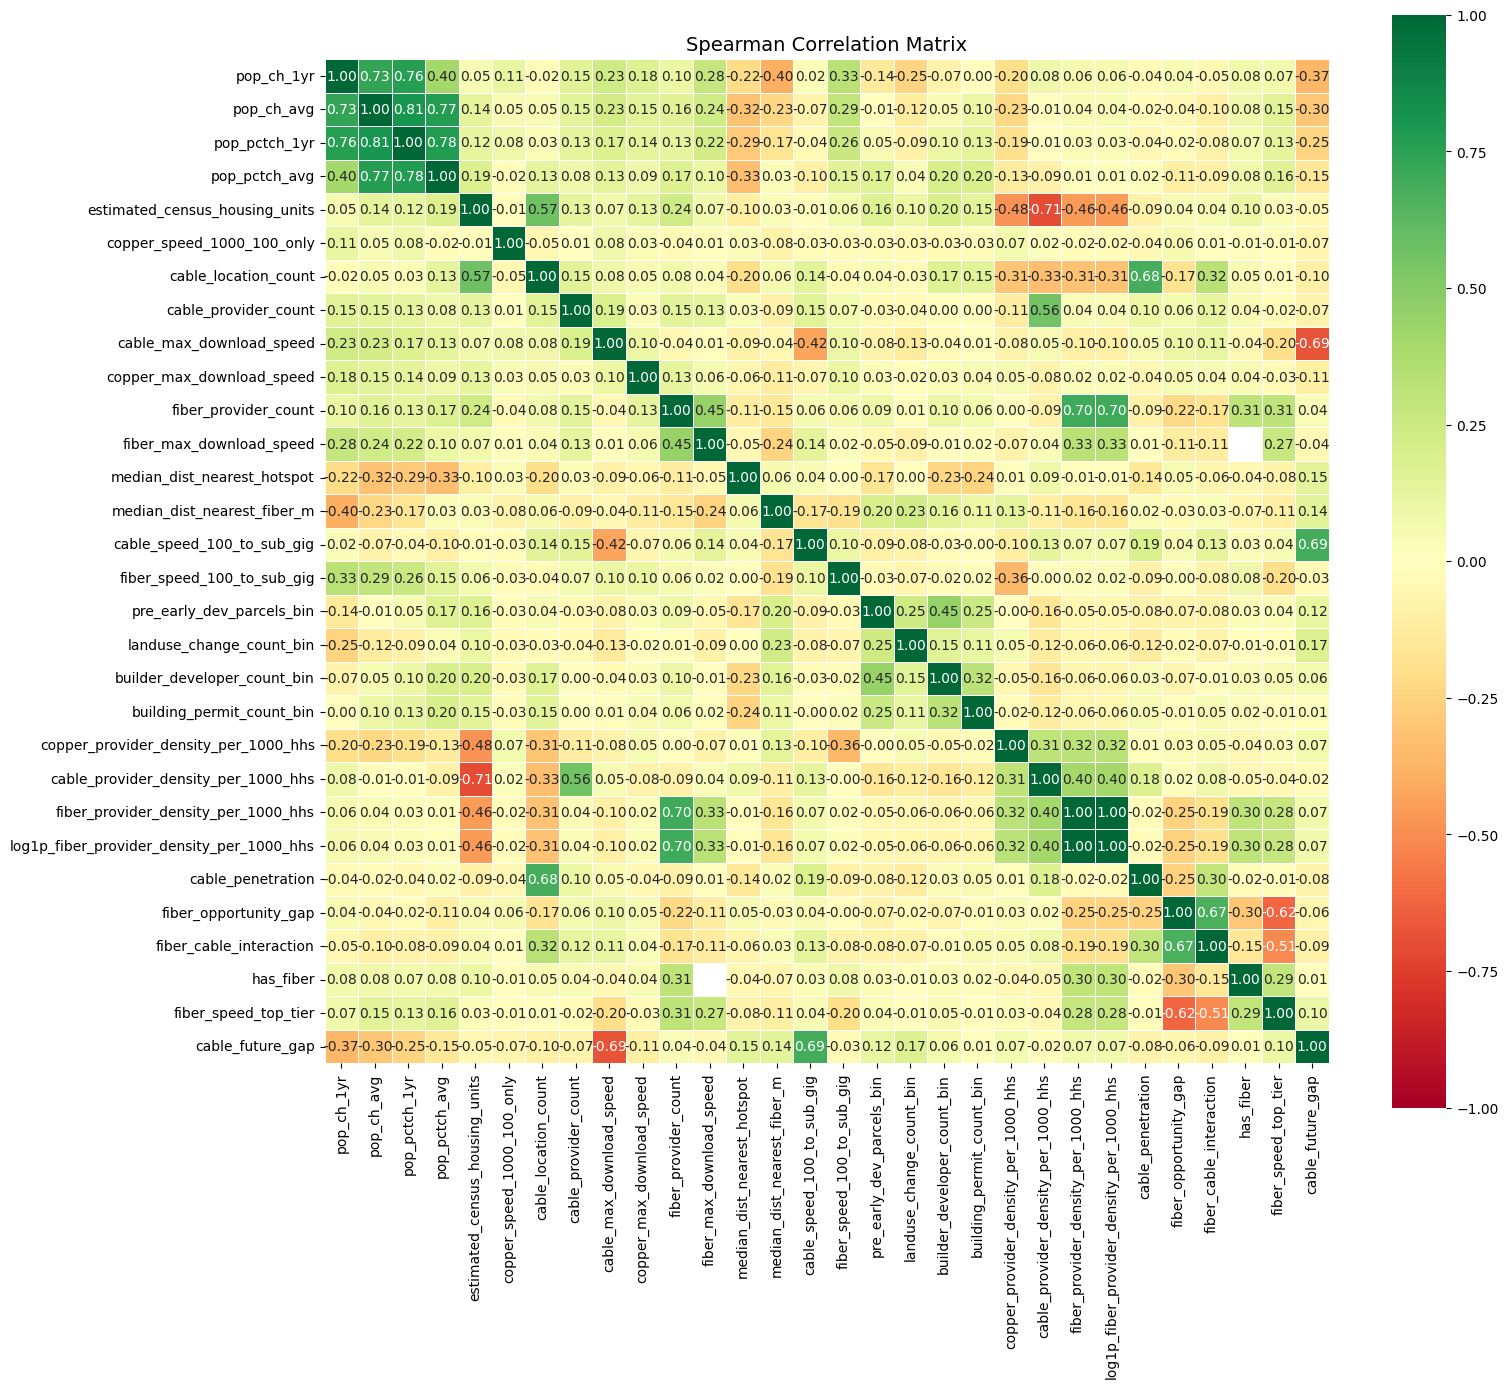

In [5]:
# Compute correlation matrix
spearman_corr_matrix = plot_correlation_heatmap(tract_df_corr, method='spearman',cmap= "RdYlGn")
print(spearman_corr_matrix)

In [6]:
# Compute top correlations: pearson
top_correlations_sp = get_top_correlations(tract_df_corr, method="spearman", n=30,min_abs_corr=0.4)
print("Top correlations with target (spearman):")
print(top_correlations_sp)

Top correlations with target (spearman):
                              feature_1  \
0   fiber_provider_density_per_1000_hhs   
1                            pop_ch_avg   
2                         pop_pctch_1yr   
3                            pop_ch_avg   
4                            pop_ch_1yr   
5                            pop_ch_1yr   
6        estimated_census_housing_units   
7                  fiber_provider_count   
8                  fiber_provider_count   
9            cable_speed_100_to_sub_gig   
10             cable_max_download_speed   
11                 cable_location_count   
12                fiber_opportunity_gap   
13                fiber_opportunity_gap   
14       estimated_census_housing_units   
15                 cable_provider_count   
16              fiber_cable_interaction   
17       estimated_census_housing_units   
18       estimated_census_housing_units   
19       estimated_census_housing_units   
20                 fiber_provider_count   
21           